In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from collections import defaultdict

DATASET_PATH = "/content/drive/MyDrive/ISBInternshipAIML/datasets"
assert os.path.exists(DATASET_PATH), f"Path not found: {DATASET_PATH}"

# List genres and first few files for quick verification
genres = [d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))]
print("Found genres:", genres)

genre_files = defaultdict(list)

print("Searching for music files...")
for root, dirs, files in os.walk(DATASET_PATH):
    if root == DATASET_PATH:
        continue

    relative_path = os.path.relpath(root, DATASET_PATH)
    genre = relative_path.split(os.sep)[0]

    for file in files:
        if file.lower().endswith(".mp3"):
            full_path = os.path.join(root, file)
            genre_files[genre].append(full_path)

print("\n--- Scan Complete ---")
found_genres = list(genre_files.keys())
print("Found genres:", found_genres if found_genres else "None")

for genre, files in genre_files.items():
    example_filenames = [os.path.basename(f) for f in files[:3]]
    print(f"\n{genre}: {len(files)} mp3 files found (example 3):", example_filenames)

Found genres: ['Hip-Hop', 'film', 'Pop', 'metal', 'Folk', 'Devotional', 'EDM', 'Rock', 'Classical']
Searching for music files...

--- Scan Complete ---
Found genres: ['Hip-Hop', 'film', 'Pop', 'metal', 'Folk', 'Devotional', 'EDM', 'Rock', 'Classical']

Hip-Hop: 201 mp3 files found (example 3): ['hiphop_4.mp3', 'hiphop_2.mp3', 'hiphop_3.mp3']

film: 166 mp3 files found (example 3): ['film_55.mp3', 'film_52.mp3', 'film_50.mp3']

Pop: 188 mp3 files found (example 3): ['popEnglish_01.mp3', 'popEnglish_03.mp3', 'popEnglish_04.mp3']

metal: 533 mp3 files found (example 3): ['Metal_01.mp3', 'Metal_02.mp3', 'Metal_03.mp3']

Folk: 210 mp3 files found (example 3): ['Folk_Telugu_46.mp3', 'Folk_Telugu_2.mp3', 'Folk_Telugu_21.mp3']

Devotional: 113 mp3 files found (example 3): ['Arey-O-Jangama_01.mp3', 'Bilwashtakam_02.mp3', 'Hara Hara Shiva Om_03.mp3']

EDM: 279 mp3 files found (example 3): ['hindi_72.mp3', 'hindi_08.mp3', 'hindi_24.mp3']

Rock: 27 mp3 files found (example 3): ['Rock_07.mp3', 'Roc

In [3]:
# Install dependencies
!pip install -q tensorflow scikit-learn matplotlib tqdm

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
import os

# Load the MFCC features
FEATURES_FILE = "/content/drive/MyDrive/ISBInternshipAIML/features_mfcc_5s.npz"
data = np.load(FEATURES_FILE, allow_pickle=True)
X = data["X"]
y = data["y"]
label_map = data["label_map"].item()
inv_label_map = {v: k for k, v in label_map.items()}

print("Loaded features:", X.shape, "Labels:", len(np.unique(y)))
print("Genres:", inv_label_map)


Loaded features: (1863, 20) Labels: 9
Genres: {0: 'Hip-Hop', 1: 'film', 2: 'Classical', 3: 'Pop', 4: 'metal', 5: 'Folk', 6: 'Devotional', 7: 'EDM', 8: 'Rock'}


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (1490, 20) Test: (373, 20)


In [6]:
input_dim = X_train.shape[1]
n_classes = len(np.unique(y))

W1 = tf.Variable(tf.random.normal([input_dim, 32], stddev=0.1))
b1 = tf.Variable(tf.zeros([32]))
W2 = tf.Variable(tf.random.normal([32, n_classes], stddev=0.1))
b2 = tf.Variable(tf.zeros([n_classes]))

def forward_class(x):
    hidden = tf.nn.relu(tf.matmul(x, W1) + b1)
    logits = tf.matmul(hidden, W2) + b2
    return logits

# Loss: sparse categorical cross-entropy
def loss_fn(y_true, logits):
    return tf.reduce_mean(
        tf.nn.sparse_softmax_cross_entropy_with_logits(labels=y_true, logits=logits)
    )

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)


In [15]:
EPOCHS = 100
BATCH_SIZE = 64

train_data = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1000).batch(BATCH_SIZE)
test_data = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)

for epoch in range(1, EPOCHS + 1):
    epoch_loss = []
    for X_batch, y_batch in train_data:
        X_batch = tf.cast(X_batch, tf.float32)
        y_batch = tf.cast(y_batch, tf.int32)
        with tf.GradientTape() as tape:
            logits = forward_class(X_batch)
            loss = loss_fn(y_batch, logits)
        grads = tape.gradient(loss, [W1, b1, W2, b2])
        optimizer.apply_gradients(zip(grads, [W1, b1, W2, b2]))
        epoch_loss.append(loss.numpy())
    print(f"Epoch {epoch:02d} | Loss: {np.mean(epoch_loss):.4f}")


Epoch 01 | Loss: 1.1569
Epoch 02 | Loss: 1.1704
Epoch 03 | Loss: 1.1652
Epoch 04 | Loss: 1.1750
Epoch 05 | Loss: 1.1667
Epoch 06 | Loss: 1.1671
Epoch 07 | Loss: 1.1656
Epoch 08 | Loss: 1.1738
Epoch 09 | Loss: 1.1744
Epoch 10 | Loss: 1.1629
Epoch 11 | Loss: 1.1548
Epoch 12 | Loss: 1.1484
Epoch 13 | Loss: 1.1504
Epoch 14 | Loss: 1.1604
Epoch 15 | Loss: 1.1529
Epoch 16 | Loss: 1.1521
Epoch 17 | Loss: 1.1621
Epoch 18 | Loss: 1.1608
Epoch 19 | Loss: 1.1453
Epoch 20 | Loss: 1.1531
Epoch 21 | Loss: 1.1719
Epoch 22 | Loss: 1.1587
Epoch 23 | Loss: 1.1430
Epoch 24 | Loss: 1.1381
Epoch 25 | Loss: 1.1563
Epoch 26 | Loss: 1.1348
Epoch 27 | Loss: 1.1519
Epoch 28 | Loss: 1.1489
Epoch 29 | Loss: 1.1518
Epoch 30 | Loss: 1.1455
Epoch 31 | Loss: 1.1347
Epoch 32 | Loss: 1.1360
Epoch 33 | Loss: 1.1507
Epoch 34 | Loss: 1.1476
Epoch 35 | Loss: 1.1379
Epoch 36 | Loss: 1.1327
Epoch 37 | Loss: 1.1447
Epoch 38 | Loss: 1.1518
Epoch 39 | Loss: 1.1365
Epoch 40 | Loss: 1.1490
Epoch 41 | Loss: 1.1445
Epoch 42 | Loss:


Test Accuracy (MFCC): 42.09%

Classification Report:
              precision    recall  f1-score   support

     Hip-Hop       0.24      0.21      0.22        39
        film       0.35      0.21      0.26        33
   Classical       0.37      0.37      0.37        30
         Pop       0.35      0.39      0.37        38
       metal       0.55      0.64      0.59       107
        Folk       0.30      0.33      0.32        42
  Devotional       0.11      0.04      0.06        23
         EDM       0.54      0.59      0.56        56
        Rock       0.00      0.00      0.00         5

    accuracy                           0.42       373
   macro avg       0.31      0.31      0.31       373
weighted avg       0.40      0.42      0.41       373



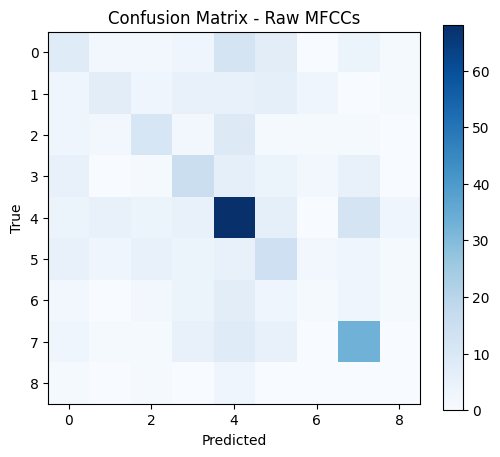

In [24]:
# Predictions on test set
logits_test = forward_class(tf.constant(X_test, dtype=tf.float32))
y_pred = tf.argmax(logits_test, axis=1).numpy()

acc = np.mean(y_pred == y_test)
print(f"\nTest Accuracy (MFCC): {acc*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[inv_label_map[i] for i in range(n_classes)]))

# Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Raw MFCCs")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()


In [9]:
# Load latent features from autoencoder
LATENT_FILE = "/content/drive/MyDrive/ISBInternshipAIML/latent_embeddings.npz"
latent = np.load(LATENT_FILE)
Z = latent["Z"]
y = latent["y"]

# Split and scale
Z_scaled = StandardScaler().fit_transform(Z)
Z_train, Z_test, y_train, y_test = train_test_split(Z_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Define a new classifier for encoded features
input_dim = Z_train.shape[1]
n_classes = len(np.unique(y))
W1_z = tf.Variable(tf.random.normal([input_dim, 64], stddev=0.1))
b1_z = tf.Variable(tf.zeros([64]))
W2_z = tf.Variable(tf.random.normal([32, n_classes], stddev=0.1))
b2_z = tf.Variable(tf.zeros([n_classes]))

optimizer_z = tf.keras.optimizers.Adam(learning_rate=0.001)

def forward_z(x):
    h = tf.nn.relu(tf.matmul(x, W1_z) + b1_z)
    return tf.matmul(h, W2_z) + b2_z


In [16]:
EPOCHS = 100
BATCH_SIZE = 64

train_ds = tf.data.Dataset.from_tensor_slices((Z_train, y_train)).shuffle(1000).batch(BATCH_SIZE)
test_ds = tf.data.Dataset.from_tensor_slices((Z_test, y_test)).batch(BATCH_SIZE)

for epoch in range(1, EPOCHS + 1):
    losses = []
    for Xb, yb in train_ds:
        Xb = tf.cast(Xb, tf.float32)
        yb = tf.cast(yb, tf.int32)
        with tf.GradientTape() as tape:
            logits = forward_z(Xb)
            loss = loss_fn(yb, logits)
        grads = tape.gradient(loss, [W1_z, b1_z, W2_z, b2_z])
        optimizer_z.apply_gradients(zip(grads, [W1_z, b1_z, W2_z, b2_z]))
        losses.append(loss.numpy())
    if epoch % 10 == 0:
        print(f"Epoch {epoch:02d} | Loss: {np.mean(losses):.4f}")


Epoch 10 | Loss: 1.7655
Epoch 20 | Loss: 1.7392
Epoch 30 | Loss: 1.7437
Epoch 40 | Loss: 1.7385
Epoch 50 | Loss: 1.7532
Epoch 60 | Loss: 1.7416
Epoch 70 | Loss: 1.7468
Epoch 80 | Loss: 1.7406
Epoch 90 | Loss: 1.7354
Epoch 100 | Loss: 1.7339


In [18]:
# Evaluate on test set
logits_test_z = forward_z(tf.constant(Z_test, dtype=tf.float32))
y_pred_z = tf.argmax(logits_test_z, axis=1).numpy()

acc_z = np.mean(y_pred_z == y_test)
print(f"\nTest Accuracy (Encoded Features): {acc_z*100:.2f}%")

print("\nClassification Report (Encoded Features):")
print(classification_report(y_test, y_pred_z, target_names=[inv_label_map[i] for i in range(n_classes)]))



Test Accuracy (Encoded Features): 30.83%

Classification Report (Encoded Features):
              precision    recall  f1-score   support

     Hip-Hop       0.35      0.31      0.33        39
        film       0.00      0.00      0.00        33
   Classical       0.17      0.27      0.21        30
         Pop       0.00      0.00      0.00        38
       metal       0.35      0.71      0.46       107
        Folk       0.06      0.02      0.03        42
  Devotional       0.10      0.04      0.06        23
         EDM       0.39      0.30      0.34        56
        Rock       0.00      0.00      0.00         5

    accuracy                           0.31       373
   macro avg       0.16      0.18      0.16       373
weighted avg       0.22      0.31      0.24       373



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
print("========== Model Comparison ==========")
print(f"Raw MFCC Accuracy:     {acc*100:.2f}%")
print(f"Encoded Feature Accuracy: {acc_z*100:.2f}%")

if acc_z >= acc:
    print("\n Encoded features perform better — your autoencoder learned useful representations!")
else:
    print("\n Raw MFCCs performed better — the encoder may have lost genre-specific info.")


========== Model Comparison ==========
Raw MFCC Accuracy:     42.09%
Encoded Feature Accuracy: 30.83%

 Raw MFCCs performed better — the encoder may have lost genre-specific info.
